In [2]:
import numpy as np
import umap
import matplotlib.pyplot as plt

In [3]:
synt_path = "/home/zagorulia/ml/train/embeddings_for_umap/source_embeddings.npy"
real_path = "/home/zagorulia/ml/train/embeddings_for_umap/target_embeddings.npy"
test_path = "/home/zagorulia/ml/train/embeddings_for_umap/test_embeddings.npy"

synt_path_da = "../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_val_best_model_val_acc.npy"
real_path_da = "../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_domain_0305_best_model_val_acc.npy"
test_path_da = "../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_cnn_metrics_14_04_best_model_val_acc.npy"

In [4]:
def load_latents(path: str) -> np.ndarray:
    X = np.load(path, allow_pickle=True)
    print(path, type(X), X.shape)
    return X

def get_umaps(synt_path, real_path, test_path):
    synt_latent = load_latents(synt_path)
    real_latent = load_latents(real_path)
    test_latent = load_latents(test_path)

    n_synt = len(synt_latent)
    n_real = len(real_latent)
    n_test = len(test_latent)

    X_all = np.vstack([synt_latent, real_latent, test_latent])

    reducer = umap.UMAP(
        n_neighbors=15,
        min_dist=0.1,
        n_components=2,
        metric="cosine",
        # random_state=42,
    )

    X_umap = reducer.fit_transform(X_all)

    synt_umap = X_umap[:n_synt]
    real_umap = X_umap[n_synt:n_synt + n_real]
    test_umap = X_umap[n_synt + n_real:]
    return synt_umap, real_umap, test_umap

In [5]:
synt_umap, real_umap, test_umap = get_umaps(synt_path, real_path, test_path)
synt_umap_da, real_umap_da, test_umap_da = get_umaps(synt_path_da, real_path_da, test_path_da)

/home/zagorulia/ml/train/embeddings_for_umap/source_embeddings.npy <class 'numpy.ndarray'> (221110, 512)
/home/zagorulia/ml/train/embeddings_for_umap/target_embeddings.npy <class 'numpy.ndarray'> (131169, 512)
/home/zagorulia/ml/train/embeddings_for_umap/test_embeddings.npy <class 'numpy.ndarray'> (472, 512)
../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_val_best_model_val_acc.npy <class 'numpy.ndarray'> (221110, 512)
../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_CNN_domain_0305_best_model_val_acc.npy <class 'numpy.ndarray'> (131169, 512)
../scripts/model.ptcnn_DA_20260401-230242/latent_vectors/latent_vecs_cnn_metrics_14_04_best_model_val_acc.npy <class 'numpy.ndarray'> (472, 512)


/tmp/ipykernel_32033/1561004226.py:46: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.tight_layout()


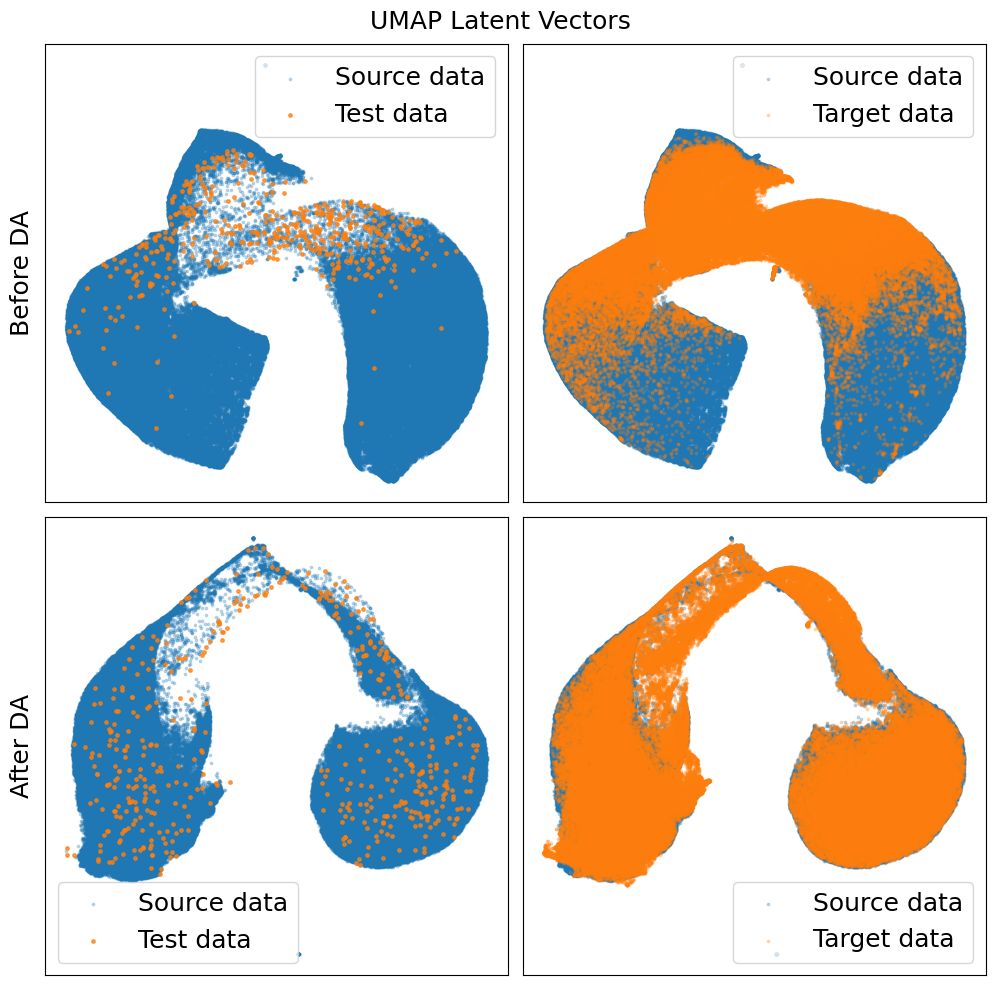

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

axes[0][0].scatter(synt_umap[:, 0], synt_umap[:, 1], s=3, alpha=0.25, label="Source data")
axes[0][0].scatter(test_umap[:, 0], test_umap[:, 1], s=6, alpha=0.75, label="Test data")
axes[0][0].legend(fontsize=18)
axes[0][0].set_xticks([])
axes[0][0].set_yticks([])
axes[0][0].text(
    -0.05, 0.5,
    "Before DA",
    transform=axes[0][0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    fontsize=18,
)

axes[0][1].scatter(synt_umap[:, 0], synt_umap[:, 1], s=3, alpha=0.25, label="Source data")
axes[0][1].scatter(real_umap[:, 0], real_umap[:, 1], s=3, alpha=0.25, label="Target data")
axes[0][1].legend(fontsize=18)
axes[0][1].set_xticks([])
axes[0][1].set_yticks([])

axes[1][0].scatter(synt_umap_da[:, 0], synt_umap_da[:, 1], s=3, alpha=0.25, label="Source data")
axes[1][0].scatter(test_umap_da[:, 0], test_umap_da[:, 1], s=6, alpha=0.75, label="Test data")
axes[1][0].legend(fontsize=18)
axes[1][0].set_xticks([])
axes[1][0].set_yticks([])
axes[1][0].text(
    -0.05, 0.5,
    "After DA",
    transform=axes[1][0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    fontsize=18,
)

axes[1][1].scatter(synt_umap_da[:, 0], synt_umap_da[:, 1], s=3, alpha=0.25, label="Source data")
axes[1][1].scatter(real_umap_da[:, 0], real_umap_da[:, 1], s=3, alpha=0.25, label="Target data")
axes[1][1].legend(fontsize=18)
axes[1][1].set_xticks([])
axes[1][1].set_yticks([])

plt.suptitle("UMAP Latent Vectors", fontsize=18)
fig.tight_layout()
plt.show()

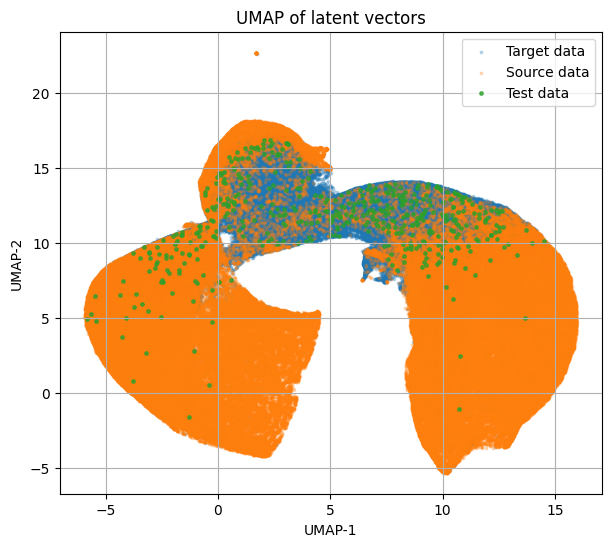

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

# plot target first as background
ax.scatter(real_umap[:, 0], real_umap[:, 1], s=3, alpha=0.25, label="Target data")
ax.scatter(synt_umap[:, 0], synt_umap[:, 1], s=3, alpha=0.25, label="Source data")
ax.scatter(test_umap[:, 0], test_umap[:, 1], s=6, alpha=0.75, label="Test data")

ax.set_title("UMAP of latent vectors")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend()
ax.grid()
plt.show()

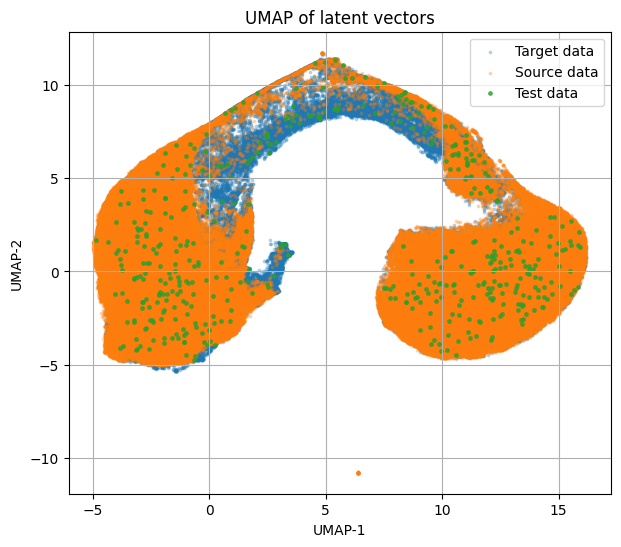

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

# plot target first as background
ax.scatter(real_umap_da[:, 0], real_umap_da[:, 1], s=3, alpha=0.25, label="Target data")
ax.scatter(synt_umap_da[:, 0], synt_umap_da[:, 1], s=3, alpha=0.25, label="Source data")
ax.scatter(test_umap_da[:, 0], test_umap_da[:, 1], s=6, alpha=0.75, label="Test data")

ax.set_title("UMAP of latent vectors")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend()
ax.grid()
plt.show()

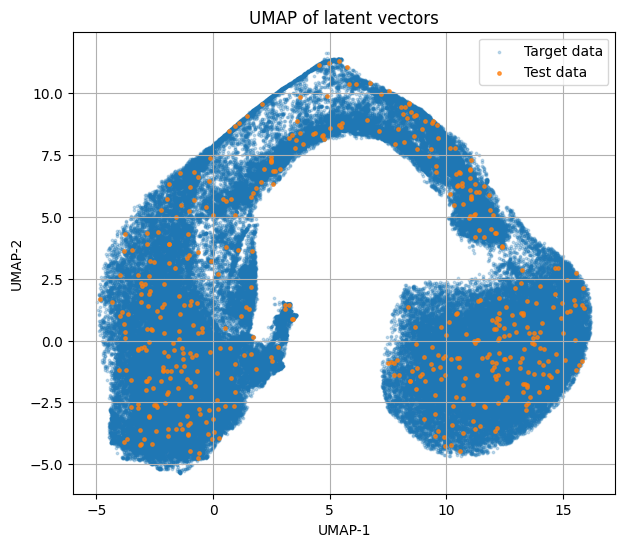

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))

# plot target first as background
ax.scatter(real_umap_da[:, 0], real_umap_da[:, 1], s=3, alpha=0.25, label="Target data")
# ax.scatter(synt_umap_da[:, 0], synt_umap_da[:, 1], s=3, alpha=0.25, label="Source data")
ax.scatter(test_umap_da[:, 0], test_umap_da[:, 1], s=6, alpha=0.75, label="Test data")

ax.set_title("UMAP of latent vectors")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend()
ax.grid()
plt.show()